<a href="https://colab.research.google.com/github/edualar19/Inteligencia-Artifical-LSTM-con-Transfering-learning-REPRODUCCIOn/blob/main/Reproduccion%20LSTM%20con%20Transfering%20learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Clonar el repositorio completo directamente en Colab
# (Reemplaza la URL con el enlace completo de tu navegador)
!git clone https://github.com/xiaohuiduan/network-traffic-dataset

# 2. Verificar las carpetas clonadas
import os
print("Carpetas clonadas en Colab:")
print(os.listdir())

Cloning into 'network-traffic-dataset'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 13 (delta 0), reused 13 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 12.05 MiB | 9.96 MiB/s, done.
Carpetas clonadas en Colab:
['.config', 'network-traffic-dataset', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np

# Definir las rutas a las carpetas (ajusta la ruta según el nombre del repositorio clonado)
# Ejemplo: 'nombre-repo/英国学术主干网'
ruta_int = 'network-traffic-dataset/英国学术主干网'  # Dataset Fuente "int"
ruta_isp = 'network-traffic-dataset/欧洲某城市核心网'  # Dataset Objetivo "isp"

# Listar los archivos que contienen para ver el nombre exacto del archivo (.csv o .txt)
print("Archivos en 'int':", os.listdir(ruta_int))
print("Archivos en 'isp':", os.listdir(ruta_isp))

Archivos en 'int': ['readme', 'isp_normal.csv', 'isp.csv']
Archivos en 'isp': ['ec_data_set.csv']


In [ ]:
import pandas as pd
import numpy as np

# Rutas exactas a los archivos identificados
path_int = 'network-traffic-dataset/英国学术主干网/isp.csv'
path_isp = 'network-traffic-dataset/欧洲某城市核心网/ec_data_set.csv'

# Cargar CSVs omitiendo líneas inconsistentes/corruptas
df_int = pd.read_csv(path_int, on_bad_lines='skip')
df_isp = pd.read_csv(path_isp, on_bad_lines='skip')

# Mostrar la estructura inicial de los datos
print("Estructura de Dataset Fuente (int):")
print(df_int.head())

print("\nEstructura de Dataset Objetivo (isp):")
print(df_isp.head())

# Extraer la última columna (valores de tráfico) como array NumPy
data_int = df_int.iloc[:, -1].values.astype(np.float32)
data_isp = df_isp.iloc[:, -1].values.astype(np.float32)

print(f"\nMuestras totales en Dataset Fuente (int): {len(data_int)}")
print(f"Muestras totales en Dataset Objetivo (isp): {len(data_isp)}")

Estructura de Dataset Fuente (int):
               #"Time"  \
0  2004-11-19 09:30:00   
1  2004-11-19 09:35:00   
2  2004-11-19 09:40:00   
3  2004-11-19 09:45:00   
4  2004-11-19 09:50:00   

   Internet traffic data (in bits) from an ISP. Aggregated traffic in the United Kingdom academic network backbone. It was collected between 19 November 2004, at 09:30 hours and 27 January 2005, at 11:11 hours. Data collected at five minute intervals.  
0                                        4838.665376                                                                                                                                                                                                         
1                                        4845.176609                                                                                                                                                                                                         
2                                        5157

In [ ]:
import torch
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Función para remover Outliers usando MAD (Sección III-A1 del paper)
def apply_mad_filter(data, n=3):
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    if mad == 0:
        return data
    lower_bound = median - n * mad
    upper_bound = median + n * mad
    return np.clip(data, lower_bound, upper_bound)

# Aplicar MAD a ambos conjuntos
data_int_cleaned = apply_mad_filter(data_int)
data_isp_cleaned = apply_mad_filter(data_isp)

# 2. Normalización Min-Max [0, 1] (Sección III-A3 del paper)
scaler_int = MinMaxScaler(feature_range=(0, 1))
scaler_isp = MinMaxScaler(feature_range=(0, 1))

int_scaled = scaler_int.fit_transform(data_int_cleaned.reshape(-1, 1)).flatten()
isp_scaled = scaler_isp.fit_transform(data_isp_cleaned.reshape(-1, 1)).flatten()

# 3. Conversión de Serie Temporal a Datos Supervisados (Step size = 10)
def create_supervised_sequences(data, step_size=10):
    X, y = [], []
    for i in range(len(data) - step_size):
        X.append(data[i : i + step_size])
        y.append(data[i + step_size])
    return np.array(X), np.array(y)

STEP_SIZE = 10

X_int_all, y_int_all = create_supervised_sequences(int_scaled, step_size=STEP_SIZE)
X_isp_all, y_isp_all = create_supervised_sequences(isp_scaled, step_size=STEP_SIZE)

# 4. Preparar Tensores de PyTorch según el diseño experimental del paper (Sección IV-A)

# A) Fuente (int): 10,000 muestras para entrenamiento base
X_source_train = torch.FloatTensor(X_int_all[:10000]).unsqueeze(-1)
y_source_train = torch.FloatTensor(y_int_all[:10000]).unsqueeze(-1)

# B) Objetivo (isp): Muestras de entrenamiento (1000, 100, 10)
X_target_train_1000 = torch.FloatTensor(X_isp_all[:1000]).unsqueeze(-1)
y_target_train_1000 = torch.FloatTensor(y_isp_all[:1000]).unsqueeze(-1)

X_target_train_100 = torch.FloatTensor(X_isp_all[:100]).unsqueeze(-1)
y_target_train_100 = torch.FloatTensor(y_isp_all[:100]).unsqueeze(-1)

X_target_train_10 = torch.FloatTensor(X_isp_all[:10]).unsqueeze(-1)
y_target_train_10 = torch.FloatTensor(y_isp_all[:10]).unsqueeze(-1)

# C) Objetivo (isp): 10,000 muestras para Prueba (Test) de evaluación
X_target_test = torch.FloatTensor(X_isp_all[1000:11000]).unsqueeze(-1)
y_target_test = torch.FloatTensor(y_isp_all[1000:11000]).unsqueeze(-1)

print(" Preprocesamiento completado con éxito:")
print(f" - Fuente (int) Entrenamiento Shape: {X_source_train.shape}")
print(f" - Objetivo (isp) Entrenamientos Shapes: {X_target_train_1000.shape}, {X_target_train_100.shape}, {X_target_train_10.shape}")
print(f" - Objetivo (isp) Test Shape: {X_target_test.shape}")

 Preprocesamiento completado con éxito:
 - Fuente (int) Entrenamiento Shape: torch.Size([10000, 10, 1])
 - Objetivo (isp) Entrenamientos Shapes: torch.Size([1000, 10, 1]), torch.Size([100, 10, 1]), torch.Size([10, 10, 1])
 - Objetivo (isp) Test Shape: torch.Size([10000, 10, 1])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. Definición de la clase del Modelo LSTM (Sección III-B del paper)
class NetworkTrafficLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=23, output_size=1):
        super(NetworkTrafficLSTM, self).__init__()
        # Capa LSTM
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        # Capa fully-connected de salida
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        out, (hn, cn) = self.lstm(x)
        # Tomar el último estado oculto del paso temporal
        out = self.fc(out[:, -1, :])
        return out

# 2. Función genérica de entrenamiento
def train_lstm_model(model, X_train, y_train, epochs=50, lr=0.02, batch_size=10):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    dataset = TensorDataset(X_train, y_train)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    loss_history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for batch_X, batch_y in dataloader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * batch_X.size(0)

        epoch_loss = running_loss / len(X_train)
        loss_history.append(epoch_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Época [{epoch}/{epochs}] - Loss (MSE): {epoch_loss:.6f}")

    return loss_history

# 3. Instanciar y Entrenar el Modelo Fuente (D_S - "int")
print("=== Entrenando Modelo Base en el Dominio Fuente ('int' - 10,000 muestras) ===")
torch.manual_seed(42)  # Para reproducibilidad

source_model = NetworkTrafficLSTM(input_size=1, hidden_size=23, output_size=1)
source_loss_history = train_lstm_model(
    model=source_model,
    X_train=X_source_train,
    y_train=y_source_train,
    epochs=50,
    lr=0.02,
    batch_size=10
)

# 4. Guardar los pesos del modelo fuente entrenado (Sección III-C del paper)
torch.save(source_model.state_dict(), "source_lstm_weights.pth")
print("\nModelo Fuente entrenado con éxito y pesos guardados en 'source_lstm_weights.pth'")

=== Entrenando Modelo Base en el Dominio Fuente ('int' - 10,000 muestras) ===
Época [1/50] - Loss (MSE): 0.021965
Época [10/50] - Loss (MSE): 0.002761
Época [20/50] - Loss (MSE): 0.002427
Época [30/50] - Loss (MSE): 0.003911
Época [40/50] - Loss (MSE): 0.000663
Época [50/50] - Loss (MSE): 0.000898

Modelo Fuente entrenado con éxito y pesos guardados en 'source_lstm_weights.pth'


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd

# Función para calcular el RMSE en el conjunto de prueba (Ec. 5 del paper)
def calculate_rmse(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test)
        mse = nn.MSELoss()(predictions, y_test).item()
        rmse = np.sqrt(mse)
    return rmse

# Configuración de los 3 experimentos definidos en el artículo
experiments = [
    ("1000 filas", X_target_train_1000, y_target_train_1000),
    ("100 filas", X_target_train_100, y_target_train_100),
    ("10 filas", X_target_train_10, y_target_train_10)
]

summary_results = []

for name, X_tr, y_tr in experiments:
    print(f"\n" + "="*50)
    print(f" EXPERIMENTO EN DOMINIO OBJETIVO: {name}")
    print("="*50)

    # A) Modelo con Transfer Learning (Carga pesos preentrenados)
    print(f"\n--- 1. Entrenando Modelo Transfer Learning ({name}) ---")
    transfer_model = NetworkTrafficLSTM(input_size=1, hidden_size=23, output_size=1)
    transfer_model.load_state_dict(torch.load("source_lstm_weights.pth"))

    transfer_loss = train_lstm_model(
        model=transfer_model,
        X_train=X_tr,
        y_train=y_tr,
        epochs=50,
        lr=0.02,
        batch_size=10
    )
    rmse_transfer = calculate_rmse(transfer_model, X_target_test, y_target_test)

    # B) Modelo de Entrenamiento Directo (Inicialización desde cero)
    print(f"\n--- 2. Entrenando Modelo Directo ({name}) ---")
    torch.manual_seed(42)
    direct_model = NetworkTrafficLSTM(input_size=1, hidden_size=23, output_size=1)

    direct_loss = train_lstm_model(
        model=direct_model,
        X_train=X_tr,
        y_train=y_tr,
        epochs=50,
        lr=0.02,
        batch_size=10
    )
    rmse_direct = calculate_rmse(direct_model, X_target_test, y_target_test)

    # Almacenar métricas e historial de pérdidas
    summary_results.append({
        "Muestras": name,
        "RMSE Transfer": rmse_transfer,
        "RMSE Directo": rmse_direct,
        "Transfer Loss Hist": transfer_loss,
        "Direct Loss Hist": direct_loss
    })

# Mostrar cuadro comparativo final
df_res = pd.DataFrame(summary_results)[["Muestras", "RMSE Transfer", "RMSE Directo"]]
print("\n" + "="*60)
print(" RESULTADOS FINALES DE RMSE (TEST: 10,000 FILAS ISP)")
print("="*60)
print(df_res.to_string(index=False))


 EXPERIMENTO EN DOMINIO OBJETIVO: 1000 filas

--- 1. Entrenando Modelo Transfer Learning (1000 filas) ---
Época [1/50] - Loss (MSE): 0.004011
Época [10/50] - Loss (MSE): 0.002376
Época [20/50] - Loss (MSE): 0.002545
Época [30/50] - Loss (MSE): 0.001820
Época [40/50] - Loss (MSE): 0.002814
Época [50/50] - Loss (MSE): 0.002269

--- 2. Entrenando Modelo Directo (1000 filas) ---
Época [1/50] - Loss (MSE): 0.159874
Época [10/50] - Loss (MSE): 0.003299
Época [20/50] - Loss (MSE): 0.003058
Época [30/50] - Loss (MSE): 0.002911
Época [40/50] - Loss (MSE): 0.007283
Época [50/50] - Loss (MSE): 0.004744

 EXPERIMENTO EN DOMINIO OBJETIVO: 100 filas

--- 1. Entrenando Modelo Transfer Learning (100 filas) ---
Época [1/50] - Loss (MSE): 0.000606
Época [10/50] - Loss (MSE): 0.000253
Época [20/50] - Loss (MSE): 0.000208
Época [30/50] - Loss (MSE): 0.000207
Época [40/50] - Loss (MSE): 0.000208
Época [50/50] - Loss (MSE): 0.000207

--- 2. Entrenando Modelo Directo (100 filas) ---
Época [1/50] - Loss (MSE

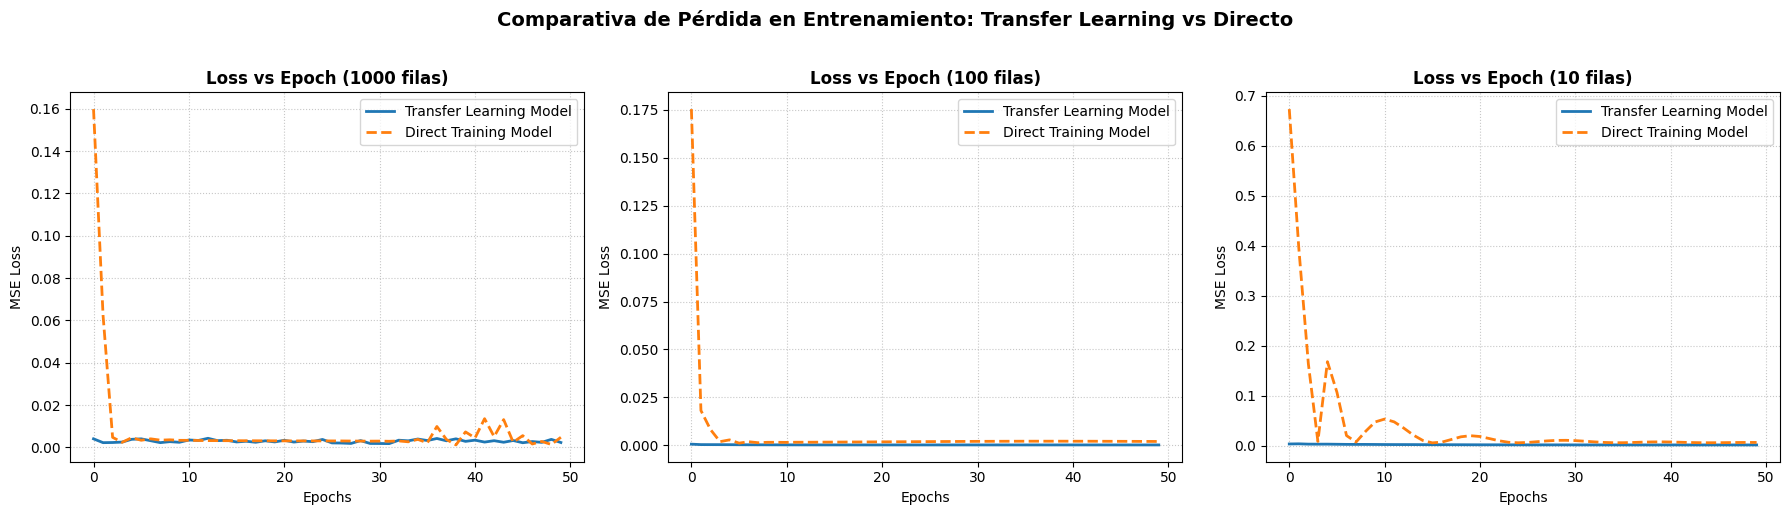

In [ ]:
import matplotlib.pyplot as plt

# Crear figura con 3 subgráficos (1000, 100 y 10 filas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, res in enumerate(summary_results):
    axes[idx].plot(res["Transfer Loss Hist"], label="Transfer Learning Model", color="#1f77b4", linewidth=2)
    axes[idx].plot(res["Direct Loss Hist"], label="Direct Training Model", color="#ff7f0e", linestyle="--", linewidth=2)
    axes[idx].set_title(f"Loss vs Epoch ({res['Muestras']})", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Epochs")
    axes[idx].set_ylabel("MSE Loss")
    axes[idx].legend()
    axes[idx].grid(True, linestyle=':', alpha=0.7)

plt.suptitle("Comparativa de Pérdida en Entrenamiento: Transfer Learning vs Directo", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("figura_7_reproduccion.png", dpi=300, bbox_inches='tight')
plt.show()
